# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

Shape: (28221, 10)

Columns: ['ID', 'OPEID', 'Institution Name', 'City', 'State', 'Foreign Gift Received Date', 'Foreign Gift Amount', 'Gift Type', 'Country of Giftor', 'Giftor Name']
count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64


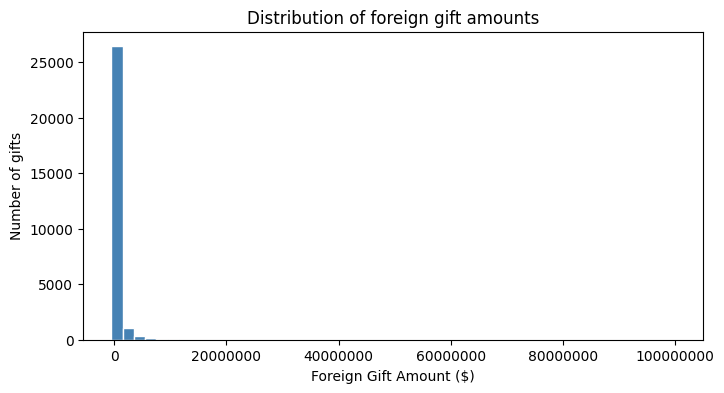

In [ ]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("./data/ForeignGifts_edu.csv")
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
df.head()
# print(df.isna().sum())

print(df["Foreign Gift Amount"].describe())

plt.figure(figsize=(8, 4))
plt.hist(df["Foreign Gift Amount"], bins=50, color="steelblue", edgecolor="white")
plt.xlabel("Foreign Gift Amount ($)")
plt.ylabel("Number of gifts")
plt.title("Distribution of foreign gift amounts")
plt.ticklabel_format(style="plain")
plt.show()




Gift amounts are wildly lopsided. Almost every gift is fairly ordinary, with the middle of the pack sitting in the thousands to low hundreds of thousands, but a small handful are enormous, and those few carry most of the money. That is why the average comes out many times larger than the typical gift, and why the histogram collapses into one tall bar with a long empty stretch beside it. The scale is being set by a few outliers rather than by the bulk of the data. There are two things worth noting. Some records are zero or negative, which probably means refunds or corrections rather than real gifts, and those may cause trouble when we take logs later. Also, the largest value repeats several times at just under a hundred million, so there may be a cap on the data collection which may influence results more since those donations are actually much larger then. represented in the set. 

Share of gifts under $2M: 0.953
Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64
Gift Type
Contract         0.6121
Monetary Gift    0.3875
Real Estate      0.0004
Name: proportion, dtype: float64


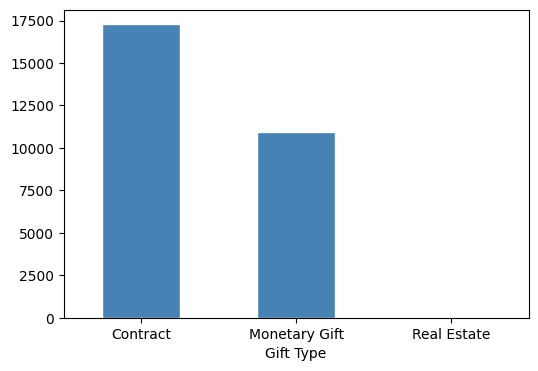

In [10]:
small_gifts = df[df["Foreign Gift Amount"] < 2000000]
print("Share of gifts under $2M:", round(len(small_gifts) / len(df), 3))


counts = df["Gift Type"].value_counts()
print(counts)

proportions = df["Gift Type"].value_counts(normalize=True)
print(proportions.round(4))

plt.figure(figsize=(6, 4))
counts.plot(kind="bar", color="steelblue", edgecolor="white")
plt.xticks(rotation=0)
plt.show()

Rows dropped: 24


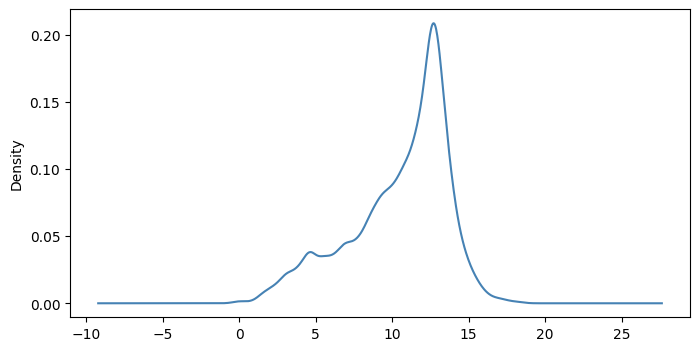

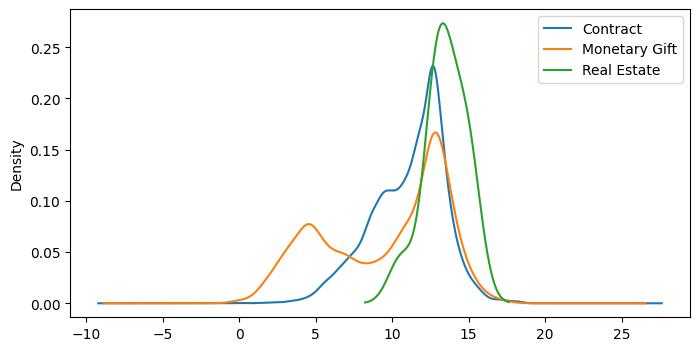

                 count   mean   std    min    25%    50%    75%    max
Gift Type                                                             
Contract       17250.0  11.12  2.39   0.00   9.54  11.61  12.81  18.42
Monetary Gift  10936.0   9.55  4.02   0.00   5.52  10.82  12.90  17.70
Real Estate       11.0  13.48  1.34  10.58  12.82  13.41  14.51  15.28


In [15]:
import scipy
positive = df[df["Foreign Gift Amount"] > 0].copy()
print("Rows dropped:", len(df) - len(positive))

positive["Log Amount"] = np.log(positive["Foreign Gift Amount"])

plt.figure(figsize=(8, 4))
positive["Log Amount"].plot(kind="density", color="steelblue")
plt.show()


plt.figure(figsize=(8, 4))

for gift_type in ["Contract", "Monetary Gift", "Real Estate"]:
    subset = positive[positive["Gift Type"] == gift_type]
    subset["Log Amount"].plot(kind="density", label=gift_type)

plt.legend()
plt.show()

print(positive.groupby("Gift Type")["Log Amount"].describe().round(2))

Taking logs fixes the readability problem immediately. What was a single spike against an empty axis becomes a clear shape with a strong peak around a few hundred thousand dollars. But it is not a clean bell curve. There is a second, smaller hump far down at the low end, around fifty to a few hundred dollars, plus a shoulder in the mid range. That tells us we are not looking at one population of gifts but several kinds of transaction mixed together.

Splitting by type shows what those humps are. The low bump belongs almost entirely to monetary gifts, which makes sense: small individual donations of a hundred dollars are common, while nobody signs a research contract for that amount. Contracts stay clustered fairly tightly around the main peak, since they are negotiated agreements and tend to fall in a predictable band. Gifts are spread much wider and carry that long thin tail of small donations, which is why their average ends up lower even though both types peak in roughly the same place. The real estate curve looks tall and tidy, but it rests on only eleven properties, so its shape is mostly an artifact of the smoothing rather than a finding.

In [21]:
gifts_by_count = df.groupby("Country of Giftor").size()
top_by_count = gifts_by_count.sort_values(ascending=False).head(15)
print(top_by_count)

gifts_by_amount = df.groupby("Country of Giftor")["Foreign Gift Amount"].sum()
top_by_amount = gifts_by_amount.sort_values(ascending=False).head(15)
print(top_by_amount)

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
dtype: int64
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64


In [27]:
by_giftor = df.groupby("Giftor Name")["Foreign Gift Amount"].sum()
top_giftors = by_giftor.sort_values(ascending=False).head(10)
print(top_giftors)

print("\nNumber of distinct named giftors:", df["Giftor Name"].nunique())
print("Rows with no giftor name:", df["Giftor Name"].isna().sum())

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Name: Foreign Gift Amount, dtype: int64

Number of distinct named giftors: 8993
Rows with no giftor name: 3751


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 8fd3f17d63ddfced44326e6bb185a281816e4868
- **AI tool and model used:** Claude Opus 5

### *Prompts used

1. can you take a look at this notebook, and my solutions to the corresponding code solutions. Can you provide 5 potential revisions to this code. Make the revisions centered around how to make the data analysis better and more robust rather than suggesting efficiency or performance revisions. Also provide a brief justification as to why you think the change should occur and explain the change:
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]
### 1. Standardize country and giftor names before grouping
 
The outputs show the same entity split across several labels. "SOUTH KOREA" (811) and "KOREA" (452) appear as separate rows. Combined, they total 1,263 gifts, which would move Korea above Hong Kong in the top 15. In Q6, "Qatar Foundation," "Qatar Foundation/Qatar National Res," and "Qatar Foundation for Education" together total about \$2.34B, roughly double what the top entry shows.
 
The fix is to normalize case and whitespace, then build a small mapping dictionary after looking at the variants. Some names also look cut off at about 35 characters (e.g., "Qatar National Res"), which is part of why the variants multiply. Before merging, check the giftor names on the "KOREA" rows to confirm they're South Korean. For the Qatar variants, decide whether affiliates count as the parent organization, and document that choice.
 
```python
for col in ["Country of Giftor", "Giftor Name"]:
    df[col] = df[col].str.strip().str.upper()
 
print(sorted(df["Country of Giftor"].dropna().unique()))   # scan for variants
print(sorted(n for n in df["Giftor Name"].dropna().unique() if "QATAR" in n))
 
df["Country of Giftor"] = df["Country of Giftor"].replace({"KOREA": "SOUTH KOREA"})
giftor_map = {"QATAR FOUNDATION/QATAR NATIONAL RES": "QATAR FOUNDATION",
              "QATAR FOUNDATION FOR EDUCATION": "QATAR FOUNDATION"}
df["Giftor Name"] = df["Giftor Name"].replace(giftor_map)
```
 
### 2. Account for missing and anonymous giftors in Q6
 
By default, `groupby` silently drops rows where the key is missing. That means the 3,751 rows with no giftor name (about 13% of the data) vanish from the Q6 ranking without their dollars ever being reported. Separately, "Anonymous" at #4 isn't one giftor. It's a bucket of many unrelated donors, so ranking it next to named organizations inflates it. The conclusion should state how much money can't be attributed to anyone.
 
```python
named = (df["Giftor Name"].notna()
         & ~df["Giftor Name"].str.contains("ANONYMOUS", case=False, na=False))
 
unattributed = df.loc[~named, "Foreign Gift Amount"].sum()
print(f"Unattributed dollars: {unattributed:,.0f} "
      f"({unattributed / df['Foreign Gift Amount'].sum():.1%} of total)")
 
print(df[named].groupby("Giftor Name")["Foreign Gift Amount"].sum().nlargest(10))
print("Missing countries:", df["Country of Giftor"].isna().sum())
```
 
### 3. Treat zero, negative, and placeholder amounts the same way in every question
 
Right now the 24 non-positive rows are dropped for the log plots but kept in the histogram, the `describe()` output, and the country and giftor totals. Each question is therefore answered on a slightly different dataset.
 
The log summary also shows a minimum of 0.00 for both contracts and monetary gifts. That means some gifts are recorded at \$1, which looks like a placeholder rather than a real amount, and those values pull the left tail of the density plot outward.
 
Inspect these rows, then make one documented decision per purpose. For example, negatives could be kept in totals as net corrections, since refunds reduce what was actually given, but excluded when describing gift sizes.
 
```python
amt = df["Foreign Gift Amount"]
print("Negative:", (amt < 0).sum(), "| Zero:", (amt == 0).sum(),
      "| $1:", (amt == 1).sum())
print(df[amt <= 1].sort_values("Foreign Gift Amount").head(15))
 
df["valid_size"] = amt > 1          # adjust the rule after inspecting
sizes = df[df["valid_size"]].copy() # use for Q2.2 and Q2.4 distribution work
```
 
### 4. Verify the "\$100M cap" claim and put numbers on the concentration claims
 
The Phase 1 writeup says the largest value repeats several times just under \$100M and suggests a data-collection cap. However, `describe()` shows the maximum is exactly \$100,000,000, and nothing in the notebook tests whether a cap exists. A cap is a strong claim, because it would mean the data understates the largest gifts. It needs evidence, since round numbers at the top could simply be large contracts written in round figures.
 
Likewise, "a small handful carry most of the money" should come with a number. The mean (\$588K) is already about six times the median (\$95K). A histogram with log-spaced bins would also show the shape that the raw-scale histogram hides.
 
```python
print(amt.nlargest(15))
print((amt == amt.max()).sum(), "gifts at exactly the maximum")
 
pos = amt[amt > 0].sort_values(ascending=False)
top1 = pos.head(int(len(pos) * 0.01)).sum() / pos.sum()
print(f"Top 1% of gifts = {top1:.1%} of all dollars")
 
plt.hist(pos, bins=np.logspace(0, np.log10(pos.max()), 50))
plt.xscale("log"); plt.xlabel("Gift amount ($, log scale)"); plt.show()
```
 
### 5. Show whether each country's rank in Q5 rests on one deal or many
 
Sums of heavy-tailed data are fragile. Bermuda ranks #5 by amount but isn't in the top 15 by count, which suggests its total rests on a few large transfers. Qatar is #1 by amount but #11 by count.
 
Adding the median gift, the share of the total that comes from the single largest gift, and the number of distinct institutions tells the reader what each country's rank actually reflects. Without that context, "top countries by amount" can be read as broad engagement when it's really one contract.
 
```python
g = df.groupby("Country of Giftor")
stats = g["Foreign Gift Amount"].agg(n_gifts="size", total="sum",
                                     median="median", largest="max")
stats["largest_share"] = stats["largest"] / stats["total"]
stats["n_institutions"] = g["Institution Name"].nunique()
print(stats.sort_values("total", ascending=False).head(15).round(2))
```


### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | reject | This is a good point to bring up, but there is also the flip side where the giftors are actually distinct entities, so implementing this change requires us to make assumptions on the data that we cannot confirm. |
| 2 | Accept | This is a good addition. It allows to have more representative data without these anonymous donors inflating or influencing our analysis. It allows us to do more meaningful analysis on the data we actually care about.|
| 3 | Accept | This revision makes our entire analysis more consistent and allows us to make meaningful comparisons between the different axes we are examining. It is important to remain consistent, since without it, we cannot attribute differences in measurements to data inconsistency or true differences|
| 4 | reject | This change is not necessary since we did confirm that there is a cap in the amount column|
| 5 | Accept | I like the intuition of the change here in that it is important to make sure we are making claims that are properly backed by the data, and the distribution of dollars relative to donor count and individual entities who donated them is important. Without it, we would be making the claim that a country might be more "engaged" through donations to a university when in actuality it is just a couple of individual entities donating a large sum of money instead of lots of different interested groups. Maybe mapping to country GDP or some other economic standard would also help us get a better understand of that countries "engagement" as a claim/ observation|

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

Shape: (28221, 10)

Columns: ['ID', 'OPEID', 'Institution Name', 'City', 'State', 'Foreign Gift Received Date', 'Foreign Gift Amount', 'Gift Type', 'Country of Giftor', 'Giftor Name']
Negative: 24 | Zero: 0 | $1: 38
          ID   OPEID                             Institution Name      City  \
18485  18486  270700  Columbia University in the City of New York  New York   
18864  18865  270700  Columbia University in the City of New York  New York   
3390    3391  113100           California Institute of Technology  Pasadena   
18404  18405  270700  Columbia University in the City of New York  New York   
18939  18940  270700  Columbia University in the City of New York  New York   
18865  18866  270700  Columbia University in the City of New York  New York   
18409  18410  270700  Columbia University in the City of New York  New York   
18467  18468  270700  Columbia University in the City of New York  New York   
18518  18519  270700  Columbia University in the City of New York  New Yo

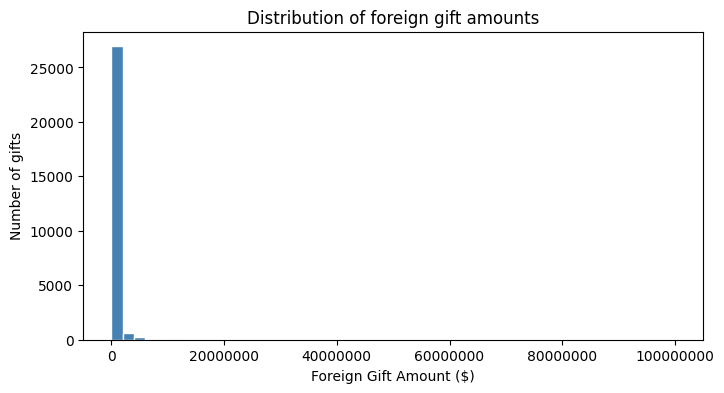

Share of gifts under $2M: 0.953
Gift Type
Contract         17246
Monetary Gift    10902
Real Estate         11
Name: count, dtype: int64
Gift Type
Contract         0.6125
Monetary Gift    0.3872
Real Estate      0.0004
Name: proportion, dtype: float64


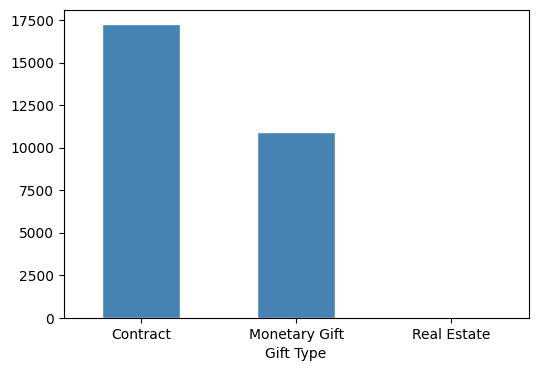

Rows dropped: 0


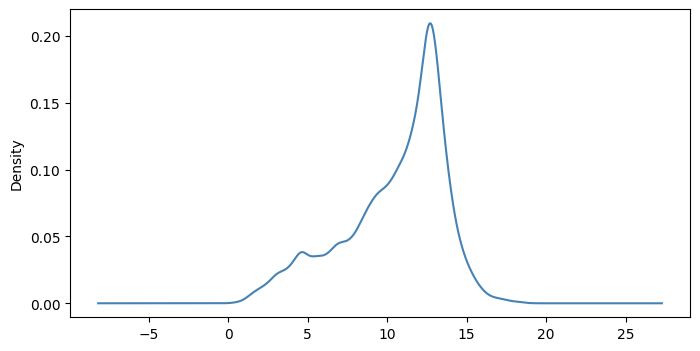

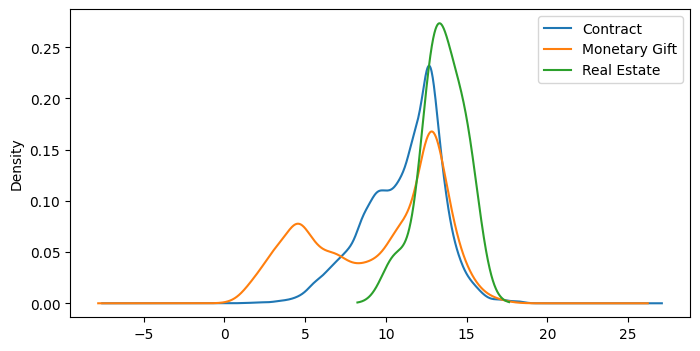

                 count   mean   std    min    25%    50%    75%    max
Gift Type                                                             
Contract       17246.0  11.13  2.39   1.10   9.54  11.61  12.81  18.42
Monetary Gift  10902.0   9.58  3.99   0.69   5.62  10.82  12.90  17.70
Real Estate       11.0  13.48  1.34  10.58  12.82  13.41  14.51  15.28
Country of Giftor
ENGLAND            3647
CHINA              2457
CANADA             2334
JAPAN              1890
SWITZERLAND        1675
SAUDI ARABIA       1610
FRANCE             1430
GERMANY            1393
HONG KONG          1079
SOUTH KOREA         805
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               432
TAIWAN              381
dtype: int64
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464933696
CHINA                   1237952108
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160646
HONG KONG                8

In [29]:
# Your Phase 2 solution to the problem goes here.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("./data/ForeignGifts_edu.csv")
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
df.head()

# Revision
amt = df["Foreign Gift Amount"]
print("Negative:", (amt < 0).sum(), "| Zero:", (amt == 0).sum(),
      "| $1:", (amt == 1).sum())
print(df[amt <= 1].sort_values("Foreign Gift Amount").head(15))

df["valid_size"] = amt > 1
df_raw = df.copy()
df = df[df["valid_size"]].copy()
print("Rows removed by cleaning rule:", len(df_raw) - len(df))

print(df["Foreign Gift Amount"].describe())

plt.figure(figsize=(8, 4))
plt.hist(df["Foreign Gift Amount"], bins=50, color="steelblue", edgecolor="white")
plt.xlabel("Foreign Gift Amount ($)")
plt.ylabel("Number of gifts")
plt.title("Distribution of foreign gift amounts")
plt.ticklabel_format(style="plain")
plt.show()

small_gifts = df[df["Foreign Gift Amount"] < 2000000]
print("Share of gifts under $2M:", round(len(small_gifts) / len(df), 3))


counts = df["Gift Type"].value_counts()
print(counts)

proportions = df["Gift Type"].value_counts(normalize=True)
print(proportions.round(4))

plt.figure(figsize=(6, 4))
counts.plot(kind="bar", color="steelblue", edgecolor="white")
plt.xticks(rotation=0)
plt.show()

import scipy
positive = df[df["Foreign Gift Amount"] > 0].copy()
print("Rows dropped:", len(df) - len(positive))

positive["Log Amount"] = np.log(positive["Foreign Gift Amount"])

plt.figure(figsize=(8, 4))
positive["Log Amount"].plot(kind="density", color="steelblue")
plt.show()


plt.figure(figsize=(8, 4))

for gift_type in ["Contract", "Monetary Gift", "Real Estate"]:
    subset = positive[positive["Gift Type"] == gift_type]
    subset["Log Amount"].plot(kind="density", label=gift_type)

plt.legend()
plt.show()

print(positive.groupby("Gift Type")["Log Amount"].describe().round(2))

gifts_by_count = df.groupby("Country of Giftor").size()
top_by_count = gifts_by_count.sort_values(ascending=False).head(15)
print(top_by_count)

gifts_by_amount = df.groupby("Country of Giftor")["Foreign Gift Amount"].sum()
top_by_amount = gifts_by_amount.sort_values(ascending=False).head(15)
print(top_by_amount)

# Revision
g = df.groupby("Country of Giftor")
stats = g["Foreign Gift Amount"].agg(n_gifts="size", total="sum",
                                     median="median", largest="max")
stats["largest_share"] = stats["largest"] / stats["total"]
stats["n_institutions"] = g["Institution Name"].nunique()
print(stats.sort_values("total", ascending=False).head(15).round(2))

by_giftor = df.groupby("Giftor Name")["Foreign Gift Amount"].sum()
top_giftors = by_giftor.sort_values(ascending=False).head(10)
print(top_giftors)

print("\nNumber of distinct named giftors:", df["Giftor Name"].nunique())
print("Rows with no giftor name:", df["Giftor Name"].isna().sum())

# Revision
named = (df["Giftor Name"].notna()
         & ~df["Giftor Name"].str.contains("ANONYMOUS", case=False, na=False))

unattributed = df.loc[~named, "Foreign Gift Amount"].sum()
print(f"Unattributed dollars: {unattributed:,.0f} "
      f"({unattributed / df['Foreign Gift Amount'].sum():.1%} of total)")

print(df[named].groupby("Giftor Name")["Foreign Gift Amount"].sum().nlargest(10))
print("Missing countries:", df["Country of Giftor"].isna().sum())

### *Reflection on AI assistance
In your own words without generative AI.

I liked the proposed changes the AI made here. I think what I had prompted helped with narrowing the focus relative to the last assignment. The changes it proposed here were all relative to how we could do a better data analysis rather than code performance and I think narrowing the scope to only 5 revisions helped the model in picking meaningful changes to propose instead of minor, out of scope, changes that dont provide much value. The model bought up good points and really focused on issues that I did not think about nor were hinted at in the problem statement.